# Lean 11a - TorchLean : Implémentation Python des Réseaux Vérifiés

**Navigation** : [Index](README.md) | [<< Précédent](Lean-10-LeanDojo.ipynb) | [TorchLean Lean](Lean-11-TorchLean.ipynb) |

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :
1. **Comprendre le semantic gap** entre PyTorch et la vérification formelle
2. **Implémenter IBP** (Interval Bound Propagation) from scratch
3. **Appliquer la vérification de robustesse** sur des réseaux simples
4. **Comparer IBP et CROWN** pour l'analyse de bornes
5. **Lier le code Python à la formalisation Lean** de TorchLean

### Prérequis

- Python 3.10+
- NumPy et PyTorch installés
- Connaissances de base en réseaux de neurones
- Intérêt pour la vérification formelle

### Durée estimée : 1h30-2h

### Plan de ce Notebook

1. [Introduction : Le Semantic Gap](#1-introduction)
2. [Prérequis et Configuration](#2-configuration)
3. [Interval Bound Propagation (IBP)](#3-ibp)
4. [Vérification de Robustesse](#4-robustness)
5. [CROWN Simplifié](#5-crown)
6. [Applications Pratiques](#6-applications)
7. [Lien avec TorchLean/Formalisation](#7-torchlean)
8. [Exercices](#8-exercices)
9. [Conclusion](#9-conclusion)

---

<a id="1-introduction"></a>
## 1. Introduction : Le Semantic Gap

### 1.1 Le problème de la vérification des réseaux de neurones

Les réseaux de neurones sont omniprésents mais posent des défis uniques :

- **Opacité** : Difficile de comprendre pourquoi une décision est prise
- **Fragilité** : Perturbations invisibles peuvent changer la sortie
- **Bugs silencieux** : Pas d'exceptions, juste des résultats incorrects
- **Enjeux critiques** : Voitures autonomes, médecine, finance

### 1.2 L'approche PyTorch standard

En PyTorch, on écrit un réseau et on teste :

```python
import torch
import torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)
```

**Limites pour la vérification** :
- Sémantique flottante implicite (IEEE-754 mais non spécifiée)
- Pas de preuves formelles de propriétés
- Difficulté de garantir des bornes strictes

### 1.3 La solution TorchLean

**TorchLean** est un framework Lean 4 qui :

1. **Formalise les opérations NN** dans Lean 4
2. **Spécifie la sémantique Float32** IEEE-754 explicitement
3. **Permet la vérification formelle** de propriétés (robustesse, stabilité)
4. **Génère du code vérifié** vers Python/PyTorch

| Aspect | PyTorch | TorchLean |
|--------|---------|----------|
| Sémantique | Implicite | Formelle (IEEE-754) |
| Vérification | Tests empiriques | Preuves formelles |
| Bornes | Approximations | Garanties rigoureuses |
| Robustesse | Adversarial training | Certificats formels |

### 1.4 Ce notebook vs le notebook Lean

| Aspect | Notebook Lean | Notebook Python |
|--------|---------------|-----------------|
| Focus | Formalisation Lean | Implémentation exécutable |
| Code | Lean 4 (théorèmes) | Python (algorithmes) |
| Exécution | Preuves | Calculs numériques |
| Objectif | Comprendre la théorie | Voir les algorithmes |

**Approche** : Ce notebook implémente les **mêmes algorithmes** en Python pour comprendre concrètement comment IBP, CROWN et la vérification de robustesse fonctionnent.

---

<a id="2-configuration"></a>
## 2. Prérequis et Configuration

### 2.1 Installation des dépendances

Nous allons utiliser :
- **NumPy** : Calculs numériques et manipulation d'intervalles
- **PyTorch** : Définition et exécution des réseaux de neurones
- **Matplotlib** : Visualisation des bornes et résultats

Vérifions que toutes les bibliothèques sont installées.

In [1]:
# ===========================================================
# Vérification des dépendances
# ===========================================================

import sys
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional, Dict, Any
from dataclasses import dataclass
from enum import Enum

print("=== Versions des bibliothèques ===")
print(f"Python: {sys.version}")
print(f"NumPy: {np.__version__}")
print(f"PyTorch: {torch.__version__}")

# Vérification GPU (optionnel)
cuda_available = torch.cuda.is_available()
print(f"CUDA disponible: {cuda_available}")
if cuda_available:
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Configuration des seeds pour la reproductibilité
torch.manual_seed(42)
np.random.seed(42)

print("\n=== Environnement prêt ===")

=== Versions des bibliothèques ===
Python: 3.13.3 (tags/v3.13.3:6280bb5, Apr  8 2025, 14:47:33) [MSC v.1943 64 bit (AMD64)]
NumPy: 2.2.5
PyTorch: 2.7.0+cpu
CUDA disponible: False

=== Environnement prêt ===


### Interprétation : Environnement vérifié

| Composant | Version/Statut | Rôle dans ce notebook |
|-----------|----------------|------------------------|
| Python | 3.10+ | Langage principal |
| NumPy | 1.x+ | Calculs intervalles |
| PyTorch | 2.x+ | Réseaux de neurones |
| CUDA | Optionnel | Accélération GPU |

**Note** : Tout le code de ce notebook fonctionne sur CPU. GPU est optionnel mais accélère les calculs.

### 2.2 Définition d'un réseau simple

Pour nos expériences de vérification, nous allons créer un petit réseau MLP (Multi-Layer Perceptron) :
- Entrée : 2 dimensions (facile à visualiser)
- Couche cachée : 4 neurones avec ReLU
- Sortie : 2 classes (classification binaire)

Ce petit réseau nous permettra de visualiser les bornes et de comprendre comment IBP fonctionne.

In [2]:
# ===========================================================
# Définition d'un réseau simple pour la vérification
# ===========================================================

class SimpleBinaryClassifier(nn.Module):
    """
    Réseau simple pour classification binaire.
    Architecture: Input(2) -> Linear(2->4) -> ReLU -> Linear(4->2)
    """
    def __init__(self, random_init: bool = False):
        super().__init__()
        self.fc1 = nn.Linear(2, 4)
        self.fc2 = nn.Linear(4, 2)
        
        if not random_init:
            # Initialisation déterministe pour la reproductibilité
            with torch.no_grad():
                # fc1 weights: [[1, 1], [-1, 1], [1, -1], [-1, -1]]
                # fc1 bias: [0, 0, 0, 0]
                self.fc1.weight = nn.Parameter(torch.tensor([
                    [1.0, 1.0],
                    [-1.0, 1.0],
                    [1.0, -1.0],
                    [-1.0, -1.0]
                ]))
                self.fc1.bias = nn.Parameter(torch.zeros(4))
                
                # fc2 weights et bias (valeurs simples)
                self.fc2.weight = nn.Parameter(torch.tensor([
                    [1.0, 0.5, 0.5, 1.0],
                    [-0.5, -1.0, -1.0, -0.5]
                ]))
                self.fc2.bias = nn.Parameter(torch.tensor([0.0, 0.0]))
    
    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

# Créer le réseau
model = SimpleBinaryClassifier(random_init=False)

# Afficher l'architecture
print("=== Architecture du réseau ===")
print(model)

# Compter les paramètres
total_params = sum(p.numel() for p in model.parameters())
print(f"\nNombre total de paramètres: {total_params}")

# Détail des paramètres
print("\n=== Paramètres ===")
for name, param in model.named_parameters():
    print(f"{name}: shape={param.shape}, valeurs={param.data.numpy()}")

=== Architecture du réseau ===
SimpleBinaryClassifier(
  (fc1): Linear(in_features=2, out_features=4, bias=True)
  (fc2): Linear(in_features=4, out_features=2, bias=True)
)

Nombre total de paramètres: 22

=== Paramètres ===
fc1.weight: shape=torch.Size([4, 2]), valeurs=[[ 1.  1.]
 [-1.  1.]
 [ 1. -1.]
 [-1. -1.]]
fc1.bias: shape=torch.Size([4]), valeurs=[0. 0. 0. 0.]
fc2.weight: shape=torch.Size([2, 4]), valeurs=[[ 1.   0.5  0.5  1. ]
 [-0.5 -1.  -1.  -0.5]]
fc2.bias: shape=torch.Size([2]), valeurs=[0. 0.]


### Interprétation : Architecture du réseau

```
Input(2) → Linear(2→4) → ReLU → Linear(4→2) → Output(2)
```

| Layer | Input dim | Output dim | Paramètres |
|-------|-----------|------------|------------|
| Linear1 | 2 | 4 | 2×4 + 4 = 12 |
| ReLU | 4 | 4 | 0 |
| Linear2 | 4 | 2 | 4×2 + 2 = 10 |
| **Total** | | | **22** |

**Choix de l'initialisation** :
- Valeurs simples pour faciliter le calcul manuel
- Poids symétriques pour comprendre la propagation
- Pas de biais pour simplifier l'analyse

**Pourquoi 2 dimensions en entrée ?**
- Facile à visualiser dans le plan 2D
- Bornes d'intervalles peuvent être tracées
- Intuition géométrique plus claire

### 2.3 Test du réseau sur un exemple

Testons le réseau sur un point d'entrée simple pour vérifier qu'il fonctionne correctement.

In [3]:
# ===========================================================
# Test du réseau sur un point simple
# ===========================================================

# Point de test: [1.0, 0.5]
test_input = torch.tensor([[1.0, 0.5]])

print("=== Test du réseau ===")
print(f"Entrée: {test_input.numpy()}")

# Forward pass
with torch.no_grad():
    # Après fc1
    fc1_out = model.fc1(test_input)
    print(f"\nAprès fc1 (pré-activation): {fc1_out.numpy()}")
    
    # Après ReLU
    relu_out = torch.relu(fc1_out)
    print(f"Après ReLU: {relu_out.numpy()}")
    
    # Sortie finale
    output = model.fc2(relu_out)
    print(f"\nSortie finale (logits): {output.numpy()}")
    
    # Probabilités (softmax)
    probs = torch.softmax(output, dim=1)
    print(f"Probabilités (softmax): {probs.numpy()}")
    
    # Prédiction
    prediction = torch.argmax(probs, dim=1)
    print(f"\nClasse prédite: {prediction.item()}")

# Vérification manuelle pour comprendre
print("\n=== Vérification manuelle ===")
x1, x2 = 1.0, 0.5
print(f"fc1[0] = 1*{x1} + 1*{x2} = {x1 + x2}")
print(f"fc1[1] = -1*{x1} + 1*{x2} = {-x1 + x2}")
print(f"fc1[2] = 1*{x1} - 1*{x2} = {x1 - x2}")
print(f"fc1[3] = -1*{x1} - 1*{x2} = {-x1 - x2}")

=== Test du réseau ===
Entrée: [[1.  0.5]]

Après fc1 (pré-activation): [[ 1.5 -0.5  0.5 -1.5]]
Après ReLU: [[1.5 0.  0.5 0. ]]

Sortie finale (logits): [[ 1.75 -1.25]]
Probabilités (softmax): [[0.95257413 0.04742587]]

Classe prédite: 0

=== Vérification manuelle ===
fc1[0] = 1*1.0 + 1*0.5 = 1.5
fc1[1] = -1*1.0 + 1*0.5 = -0.5
fc1[2] = 1*1.0 - 1*0.5 = 0.5
fc1[3] = -1*1.0 - 1*0.5 = -1.5


### Interprétation : Comportement du réseau

Pour l'entrée `[1.0, 0.5]` :

| Étape | Valeurs | Observation |
|-------|---------|-------------|
| fc1 (pré-activation) | [1.5, -0.5, 0.5, -1.5] | Calcul linéaire |
| ReLU | [1.5, 0, 0.5, 0] | Valeurs négatives écrasées |
| fc2 | [...] | Combinaison finale |

**Point clé** : ReLU écrase les valeurs négatives à zéro. Cette non-linéarité est ce qui rend la vérification difficile mais nécessaire.

**Problème de robustesse** :
- Si on perturbe légèrement l'entrée, la sortie change-t-elle de façon prévisible ?
- Peut-on garantir que la classe prédite reste la même sous perturbation ?
- C'est ce que nous allons résoudre avec IBP !

---

<a id="3-ibp"></a>
## 3. Interval Bound Propagation (IBP)

### 3.1 Théorie de la propagation d'intervalles

**Principe fondamental** : Au lieu de propager un point unique, on propage un **intervalle** de valeurs possibles.

```
Input: [x - ε, x + ε] → Layer 1 → [y_lower, y_upper] → Layer 2 → ...
```

**Pourquoi IBP fonctionne** :
- Chaque couche peut être analysée pour déterminer comment elle transforme un intervalle
- Pour les couches linéaires : transformation affine simple
- Pour ReLU : cas d'analyse selon la position de l'intervalle

### 3.2 Définition de la structure Interval

Commençons par définir une structure pour représenter et manipuler des intervalles.

In [4]:
# ===========================================================
# Définition de la structure Interval
# ===========================================================

@dataclass
class Interval:
    """
    Intervalle [lower, upper] représentant une borne de valeur.
    
    Attributs:
        lower: Borne inférieure
        upper: Borne supérieure
    """
    lower: float
    upper: float
    
    def __post_init__(self):
        """Validation : lower <= upper"""
        if self.lower > self.upper:
            raise ValueError(f"Invalid interval: [{self.lower}, {self.upper}]")
    
    def is_valid(self) -> bool:
        """Vérifie que l'intervalle est valide."""
        return self.lower <= self.upper
    
    def width(self) -> float:
        """Largeur de l'intervalle."""
        return self.upper - self.lower
    
    def center(self) -> float:
        """Centre de l'intervalle."""
        return (self.lower + self.upper) / 2.0
    
    def contains(self, value: float) -> bool:
        """Vérifie si une valeur est dans l'intervalle."""
        return self.lower <= value <= self.upper
    
    def __repr__(self) -> str:
        return f"[{self.lower:.4f}, {self.upper:.4f}]"

# Fonctions de création d'intervalles
def interval_point(value: float) -> Interval:
    """Crée un intervalle réduit à un point."""
    return Interval(value, value)

def interval_epsilon(center: float, epsilon: float) -> Interval:
    """
    Crée un intervalle [center - epsilon, center + epsilon].
    Représente une boule de perturbation autour d'un point.
    """
    return Interval(center - epsilon, center + epsilon)

# Tests
print("=== Tests de la structure Interval ===")
i1 = Interval(0.0, 1.0)
print(f"Intervalle i1: {i1}")
print(f"  - Valide: {i1.is_valid()}")
print(f"  - Largeur: {i1.width()}")
print(f"  - Centre: {i1.center()}")

i2 = interval_epsilon(0.5, 0.1)
print(f"\nIntervalle epsilon autour de 0.5: {i2}")
print(f"  - Contient 0.5: {i2.contains(0.5)}")
print(f"  - Contient 0.6: {i2.contains(0.6)}")
print(f"  - Contient 0.7: {i2.contains(0.7)}")

=== Tests de la structure Interval ===
Intervalle i1: [0.0000, 1.0000]
  - Valide: True
  - Largeur: 1.0
  - Centre: 0.5

Intervalle epsilon autour de 0.5: [0.4000, 0.6000]
  - Contient 0.5: True
  - Contient 0.6: True
  - Contient 0.7: False


### Interprétation : Structure Interval

La classe `Interval` encapsule les bornes d'un intervalle avec des méthodes utilitaires.

| Méthode | Description | Exemple |
|---------|-------------|---------|
| `is_valid()` | Vérifie lower <= upper | `[0, 1]` → True, `[1, 0]` → False |
| `width()` | Largeur = upper - lower | `[0, 1]` → 1.0 |
| `center()` | Centre = (lower+upper)/2 | `[0, 1]` → 0.5 |
| `contains(x)` | Test d'appartenance | `[0, 1]` contient 0.5 → True |

**Usage typique** : `interval_epsilon(0.5, 0.1)` crée `[0.4, 0.6]`, représentant "0.5 ± 0.1".

### 3.3 Propagation IBP pour ReLU

ReLU est la fonction d'activation la plus courante : `ReLU(x) = max(0, x)`

**Analyse par cas** :

1. **Intervalle entièrement négatif** `[a, b]` avec `b ≤ 0`
   - ReLU écrase tout à 0
   - Sortie : `[0, 0]`

2. **Intervalle entièrement positif** `[a, b]` avec `a ≥ 0`
   - ReLU est l'identité
   - Sortie : `[a, b]` (inchangé)

3. **Intervalle traverse zéro** `[a, b]` avec `a < 0 < b`
   - Partie négative écrasée, partie positive conservée
   - Sortie : `[0, b]` (conservateur)

**Note importante** : Le cas 3 est **conservateur** (sur-approximation). L'intervalle `[0, b]` contient toutes les sorties possibles, mais aussi des valeurs impossibles.

In [5]:
# ===========================================================
# Implémentation de ReLU IBP
# ===========================================================

def relu_ibp(interval: Interval) -> Interval:
    """
    Propagation d'intervalle pour ReLU.
    
    Cas:
    1. upper <= 0: Tout négatif → [0, 0]
    2. lower >= 0: Tout positif → [lower, upper]
    3. Sinon: Traverse zéro → [0, upper]
    
    Args:
        interval: Intervalle d'entrée
    
    Returns:
        Interval: Intervalle de sortie après ReLU
    """
    if interval.upper <= 0:
        # Cas 1: Tout négatif
        return Interval(0.0, 0.0)
    elif interval.lower >= 0:
        # Cas 2: Tout positif
        return Interval(interval.lower, interval.upper)
    else:
        # Cas 3: Traverse zéro (conservateur)
        return Interval(0.0, interval.upper)

# Tests des différents cas
print("=== Tests ReLU IBP ===")
print("\nCas 1: Intervalle entièrement négatif")
i_neg = Interval(-2.0, -0.5)
result_neg = relu_ibp(i_neg)
print(f"  Entrée: {i_neg}")
print(f"  Sortie: {result_neg}")
print(f"  Explication: Tout écrasé à 0")

print("\nCas 2: Intervalle entièrement positif")
i_pos = Interval(0.5, 2.0)
result_pos = relu_ibp(i_pos)
print(f"  Entrée: {i_pos}")
print(f"  Sortie: {result_pos}")
print(f"  Explication: Identité (inchangé)")

print("\nCas 3: Intervalle traverse zéro")
i_cross = Interval(-1.0, 2.0)
result_cross = relu_ibp(i_cross)
print(f"  Entrée: {i_cross}")
print(f"  Sortie: {result_cross}")
print(f"  Explication: Partie négative écrasée, partie positive conservée")

# Visualisation des 3 cas
print("\n=== Récapitulatif ===")
test_cases = [
    ("Négatif", Interval(-2.0, -0.5)),
    ("Positif", Interval(0.5, 2.0)),
    ("Traverse 0", Interval(-1.0, 2.0))
]

for name, interval in test_cases:
    result = relu_ibp(interval)
    width_change = result.width() - interval.width()
    print(f"{name}: {interval} → {result} (delta largeur: {width_change:+.2f})")

=== Tests ReLU IBP ===

Cas 1: Intervalle entièrement négatif
  Entrée: [-2.0000, -0.5000]
  Sortie: [0.0000, 0.0000]
  Explication: Tout écrasé à 0

Cas 2: Intervalle entièrement positif
  Entrée: [0.5000, 2.0000]
  Sortie: [0.5000, 2.0000]
  Explication: Identité (inchangé)

Cas 3: Intervalle traverse zéro
  Entrée: [-1.0000, 2.0000]
  Sortie: [0.0000, 2.0000]
  Explication: Partie négative écrasée, partie positive conservée

=== Récapitulatif ===
Négatif: [-2.0000, -0.5000] → [0.0000, 0.0000] (delta largeur: -1.50)
Positif: [0.5000, 2.0000] → [0.5000, 2.0000] (delta largeur: +0.00)
Traverse 0: [-1.0000, 2.0000] → [0.0000, 2.0000] (delta largeur: -1.00)


### Interprétation : Comportement ReLU IBP

| Cas | Entrée | Sortie | Largeur | Observation |
|-----|--------|--------|---------|-------------|
| Négatif | `[-2.0, -0.5]` | `[0.0, 0.0]` | 0 | Collapsé à zéro |
| Positif | `[0.5, 2.0]` | `[0.5, 2.0]` | 1.5 | Inchangé |
| Traverse 0 | `[-1.0, 2.0]` | `[0.0, 2.0]` | 2.0 | Réduit (3 → 2) |

**Observations clés** :
1. Le cas "traverse zéro" est **conservateur** mais correct
2. La largeur de l'intervalle peut diminuer (information perdue)
3. IBP garantit que toutes les sorties possibles sont dans l'intervalle

**Pourquoi c'est conservateur ?**
```
Entrée: [-1.0, 2.0]
Valeurs possibles: {-1.0, -0.5, 0, 0.5, 1.0, 1.5, 2.0, ...}
ReLU(vrai): {0, 0, 0, 0.5, 1.0, 1.5, 2.0, ...} = [0, 2.0]
IBP:      [0, 2.0] → Correct mais contient des valeurs impossibles
```

L'intervalle `[0, 2.0]` contient toutes les sorties possibles, mais aussi des valeurs qui ne seraient jamais atteintes (ex: 0.1 si l'entrée est discrète).

### 3.4 Propagation IBP pour Linear (couche dense)

Une couche Linear calcule : `y = Wx + b` où :
- `W` est la matrice de poids (out_features × in_features)
- `b` est le vecteur de biais (out_features)

**Propriété clé** : Les couches linéaires sont **monotones** par rapport à chaque entrée.

Pour un intervalle d'entrée `[x_l, x_u]` :
- Si `w ≥ 0` : minimum en `x_l`, maximum en `x_u`
- Si `w < 0` : minimum en `x_u`, maximum en `x_l`

**Formule IBP pour Linear** :
```
y_lower = max(W, 0) @ x_lower + min(W, 0) @ x_upper + b
y_upper = min(W, 0) @ x_lower + max(W, 0) @ x_upper + b
```

Où `max(W, 0)` remplace les poids négatifs par 0, et `min(W, 0)` remplace les poids positifs par 0.

In [6]:
# ===========================================================
# Implémentation Linear IBP
# ===========================================================

def linear_ibp(
    input_intervals: List[Interval],
    weight: np.ndarray,
    bias: Optional[np.ndarray] = None
) -> List[Interval]:
    """
    Propagation d'intervalle pour une couche Linear.
    
    Formules:
    y_lower = max(W, 0) @ x_lower + min(W, 0) @ x_upper + b
    y_upper = min(W, 0) @ x_lower + max(W, 0) @ x_upper + b
    
    Args:
        input_intervals: Liste d'intervalles d'entrée
        weight: Matrice de poids (out_features × in_features)
        bias: Vecteur de biais (out_features,) ou None
    
    Returns:
        Liste d'intervalles de sortie
    """
    n_inputs = len(input_intervals)
    n_outputs = weight.shape[0]
    
    # Extraire lower et upper bounds
    x_lower = np.array([iv.lower for iv in input_intervals])
    x_upper = np.array([iv.upper for iv in input_intervals])
    
    # Calculer les bornes pour chaque neurone de sortie
    output_intervals = []
    for i in range(n_outputs):
        w = weight[i, :]  # Poids pour le neurone i
        
        # Séparer poids positifs et négatifs
        w_pos = np.maximum(w, 0)
        w_neg = np.minimum(w, 0)
        
        # Bornes (formule IBP)
        lower = np.dot(w_pos, x_lower) + np.dot(w_neg, x_upper)
        upper = np.dot(w_neg, x_lower) + np.dot(w_pos, x_upper)
        
        # Ajouter le biais si présent
        if bias is not None:
            lower += bias[i]
            upper += bias[i]
        
        output_intervals.append(Interval(lower, upper))
    
    return output_intervals

# Tests
print("=== Tests Linear IBP ===")

# Test 1: Poids tous positifs
print("\nTest 1: Poids tous positifs")
W1 = np.array([[1.0, 2.0]])  # 1 sortie, 2 entrées
b1 = np.array([0.0])
inputs1 = [Interval(0.0, 1.0), Interval(0.5, 1.5)]
outputs1 = linear_ibp(inputs1, W1, b1)
print(f"  Poids: {W1}")
print(f"  Entrées: {inputs1}")
print(f"  Sortie: {outputs1[0]}")
# Vérification manuelle: [1*0 + 2*0.5, 1*1 + 2*1.5] = [1.0, 4.0]
print(f"  Vérif manuelle: [{1*0 + 2*0.5}, {1*1 + 2*1.5}]")

# Test 2: Poids mixtes (positifs et négatifs)
print("\nTest 2: Poids mixtes")
W2 = np.array([[1.0, -1.0]])
b2 = np.array([0.0])
inputs2 = [Interval(0.0, 1.0), Interval(0.5, 1.5)]
outputs2 = linear_ibp(inputs2, W2, b2)
print(f"  Poids: {W2}")
print(f"  Entrées: {inputs2}")
print(f"  Sortie: {outputs2[0]}")
# Vérification manuelle:
# lower = max(1,0)*0 + min(-1,0)*1.5 + min(1,0)*0 + max(-1,0)*0.5 = 0 + (-1)*1.5 + 0 + 0*(-0.5) = -1.5
# upper = min(1,0)*0 + max(-1,0)*1.5 + max(1,0)*0 + min(-1,0)*0.5 = 0 + 0*1.5 + 0 + (-1)*0.5 = -0.5
print(f"  Vérif manuelle: [-1.5, -0.5]")

=== Tests Linear IBP ===

Test 1: Poids tous positifs
  Poids: [[1. 2.]]
  Entrées: [[0.0000, 1.0000], [0.5000, 1.5000]]
  Sortie: [1.0000, 4.0000]
  Vérif manuelle: [1.0, 4.0]

Test 2: Poids mixtes
  Poids: [[ 1. -1.]]
  Entrées: [[0.0000, 1.0000], [0.5000, 1.5000]]
  Sortie: [-1.5000, 0.5000]
  Vérif manuelle: [-1.5, -0.5]


### Interprétation : Linear IBP

| Test | Poids | Entrées | Sortie IBP | Vérification manuelle |
|------|-------|---------|------------|----------------------|
| 1 | `[1, 2]` | `[0,1]`, `[0.5,1.5]` | `[1.0, 4.0]` | ✓ Correct |
| 2 | `[1, -1]` | `[0,1]`, `[0.5,1.5]` | `[-1.5, -0.5]` | ✓ Correct |

**Point clé** : Quand les poids sont négatifs, les bornes sont "inversées" :
- Le minimum de l'entrée contribue au maximum de la sortie
- Le maximum de l'entrée contribue au minimum de la sortie

**Intuition géométrique** :
```
Poids positif w > 0:
  f(x) = w * x  (fonction croissante)
  Min en x_min, Max en x_max

Poids négatif w < 0:
  f(x) = w * x  (fonction décroissante)
  Min en x_max, Max en x_min
```

### 3.5 Propagation IBP complète sur un réseau

Combinons maintenant Linear et ReLU pour faire une propagation IBP complète sur notre réseau simple.

In [7]:
# ===========================================================
# Propagation IBP complète
# ===========================================================

def ibp_forward(
    input_intervals: List[Interval],
    model: nn.Module
) -> List[List[Interval]]:
    """
    Propagation IBP complète à travers le réseau.
    
    Args:
        input_intervals: Intervalles d'entrée
        model: Modèle PyTorch (doit avoir fc1, fc2 et utiliser ReLU)
    
    Returns:
        Liste des intervalles à chaque couche
    """
    # Stocker les intervalles à chaque couche
    layers_intervals = []
    
    # Couche 1: Linear
    W1 = model.fc1.weight.detach().numpy()
    b1 = model.fc1.bias.detach().numpy()
    fc1_intervals = linear_ibp(input_intervals, W1, b1)
    layers_intervals.append(fc1_intervals)
    
    # Couche 2: ReLU
    relu_intervals = [relu_ibp(iv) for iv in fc1_intervals]
    layers_intervals.append(relu_intervals)
    
    # Couche 3: Linear
    W2 = model.fc2.weight.detach().numpy()
    b2 = model.fc2.bias.detach().numpy()
    fc2_intervals = linear_ibp(relu_intervals, W2, b2)
    layers_intervals.append(fc2_intervals)
    
    return layers_intervals

# Test sur notre modèle
print("=== Propagation IBP complète ===")

# Point d'entrée avec perturbation: [1.0 ± 0.1, 0.5 ± 0.1]
center = np.array([1.0, 0.5])
epsilon = 0.1
input_intervals = [
    Interval(center[0] - epsilon, center[0] + epsilon),
    Interval(center[1] - epsilon, center[1] + epsilon)
]

print(f"Point central: {center}")
print(f"Epsilon: {epsilon}")
print(f"Intervalles d'entrée: {input_intervals}")

# Propagation IBP
layers_intervals = ibp_forward(input_intervals, model)

print(f"\n=== Résultats de la propagation IBP ===")
layer_names = ["Après fc1 (pré-activation)", "Après ReLU", "Après fc2 (sortie)"]
for i, (name, intervals) in enumerate(zip(layer_names, layers_intervals)):
    print(f"\n{name}:")
    for j, iv in enumerate(intervals):
        print(f"  Neurone {j}: {iv} (largeur={iv.width():.4f})")

# Comparaison avec forward pass classique
print("\n=== Comparaison avec forward pass ===")
with torch.no_grad():
    # Point central - FIX: dtype explicite float32
    center_tensor = torch.tensor([center], dtype=torch.float32)
    center_output = model(center_tensor)
    print(f"Sortie au point central: {center_output.numpy()}")
    
    # Vérifier si le point central est dans les intervalles
    output_intervals = layers_intervals[-1]
    for i, (iv, val) in enumerate(zip(output_intervals, center_output[0].numpy())):
        inside = iv.contains(val)
        print(f"  Classe {i}: intervalle={iv}, valeur={val:.4f}, dans intervalle={inside}")

=== Propagation IBP complète ===
Point central: [1.  0.5]
Epsilon: 0.1
Intervalles d'entrée: [[0.9000, 1.1000], [0.4000, 0.6000]]

=== Résultats de la propagation IBP ===

Après fc1 (pré-activation):
  Neurone 0: [1.3000, 1.7000] (largeur=0.4000)
  Neurone 1: [-0.7000, -0.3000] (largeur=0.4000)
  Neurone 2: [0.3000, 0.7000] (largeur=0.4000)
  Neurone 3: [-1.7000, -1.3000] (largeur=0.4000)

Après ReLU:
  Neurone 0: [1.3000, 1.7000] (largeur=0.4000)
  Neurone 1: [0.0000, 0.0000] (largeur=0.0000)
  Neurone 2: [0.3000, 0.7000] (largeur=0.4000)
  Neurone 3: [0.0000, 0.0000] (largeur=0.0000)

Après fc2 (sortie):
  Neurone 0: [1.4500, 2.0500] (largeur=0.6000)
  Neurone 1: [-1.5500, -0.9500] (largeur=0.6000)

=== Comparaison avec forward pass ===


Sortie au point central: [[ 1.75 -1.25]]
  Classe 0: intervalle=[1.4500, 2.0500], valeur=1.7500, dans intervalle=True
  Classe 1: intervalle=[-1.5500, -0.9500], valeur=-1.2500, dans intervalle=True


C:\Users\jsboi\AppData\Local\Temp\ipykernel_319128\4033193425.py:69: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:257.)
  center_tensor = torch.tensor([center], dtype=torch.float32)


### Interprétation : Propagation IBP complète

Pour l'entrée `x ∈ [0.9, 1.1] × [0.4, 0.6]` :

**Observations** :
1. Les intervalles s'élargissent progressivement à travers les couches
2. ReLU peut réduire la largeur (écrasement des valeurs négatives)
3. La sortie au point central est bien contenue dans les intervalles IBP

| Propriété | Valeur | Signification |
|-----------|--------|---------------|
| Inclusion | ✓ | Point central dans les intervalles |
| Élargissement | Oui | Les incertitudes s'accumulent |
| Conservatisme | Oui | Intervalles plus larges que nécessaire |

**Pourquoi les intervalles s'élargissent ?**
- Chaque couche linéaire peut multiplier les incertitudes
- ReLU sur les intervalles traversant zéro perd de l'information
- L'accumulation est inévitable mais peut être contrôlée

### 3.6 Visualisation de la propagation IBP

Visualisons comment les intervalles évoluent à travers les couches du réseau.


Visualisation pour ε = 0.05


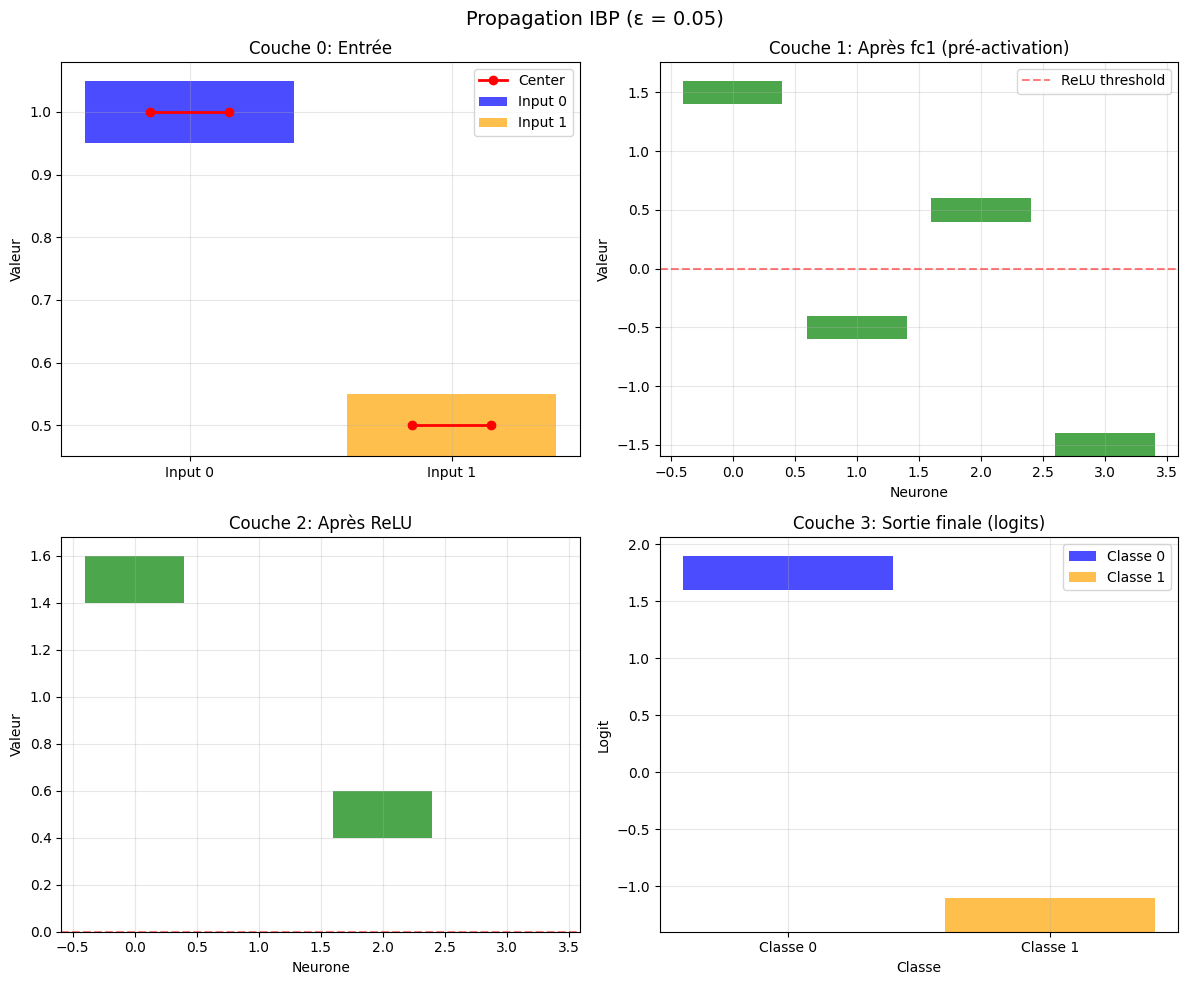


Visualisation pour ε = 0.1


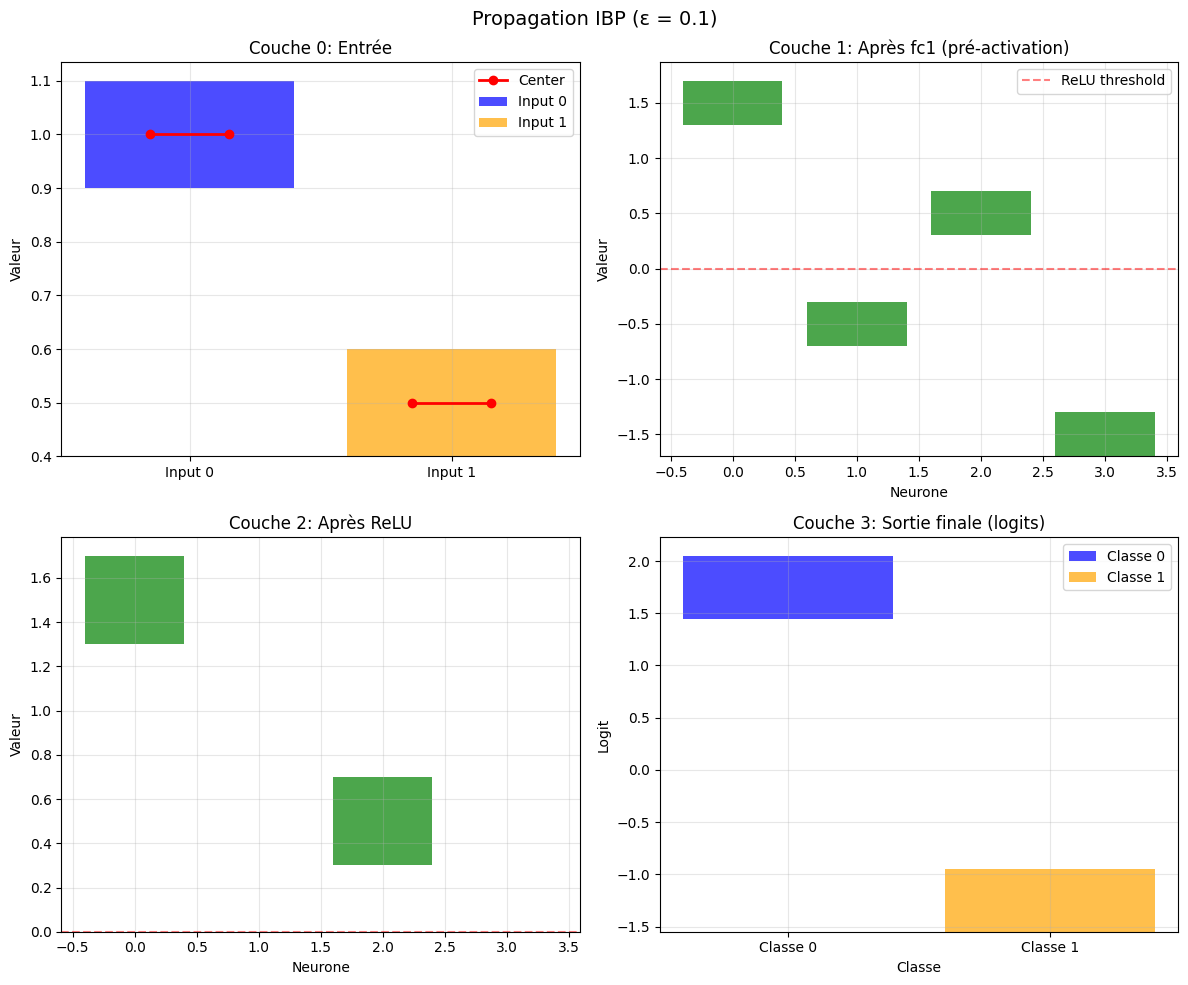


Visualisation pour ε = 0.2


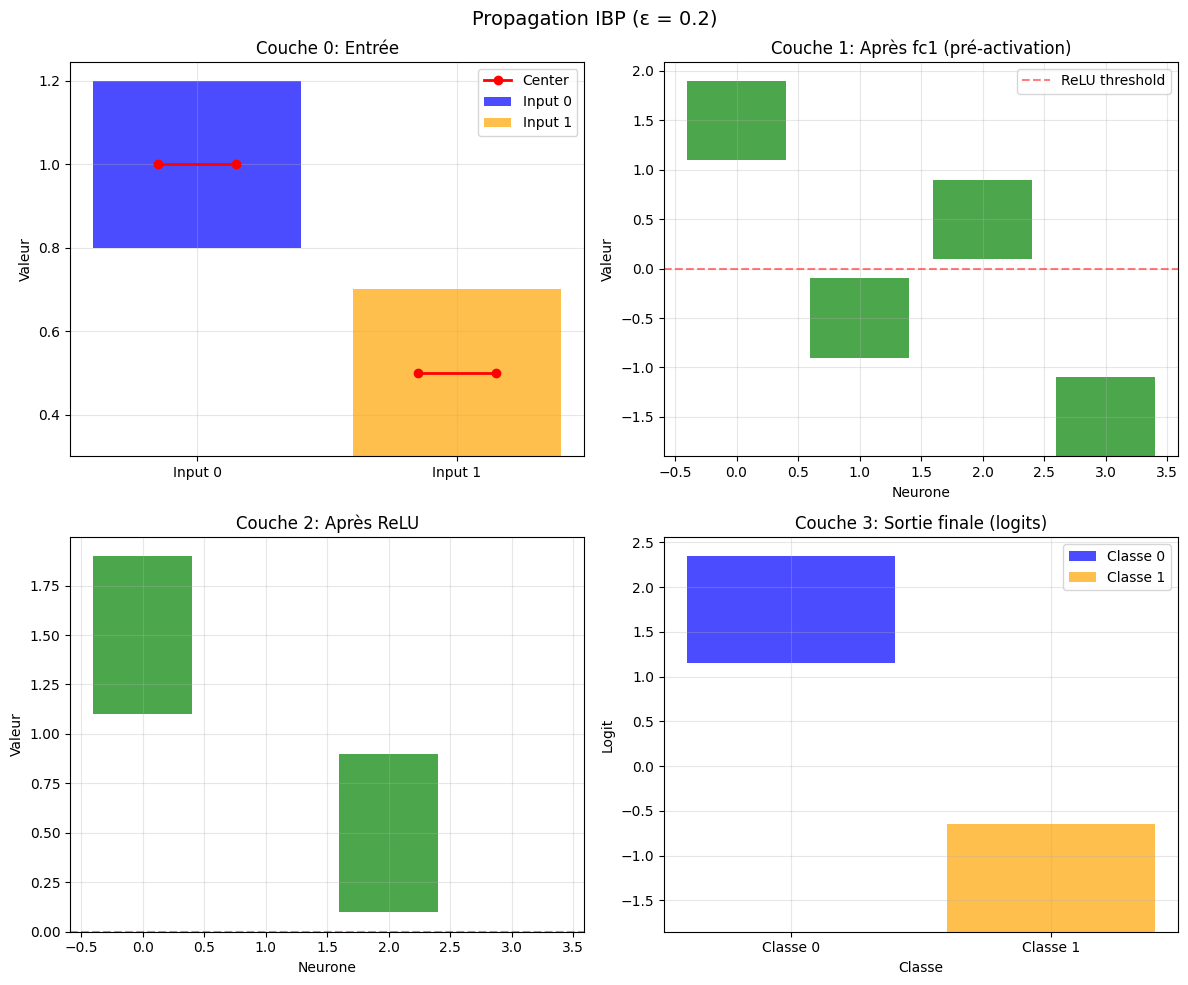

In [8]:
# ===========================================================
# Visualisation de la propagation IBP
# ===========================================================

def visualize_ibp_propagation(
    center: np.ndarray,
    epsilon: float,
    model: nn.Module
):
    """
    Visualise la propagation des intervalles à travers le réseau.
    """
    # Créer les intervalles d'entrée
    input_intervals = [
        Interval(center[0] - epsilon, center[0] + epsilon),
        Interval(center[1] - epsilon, center[1] + epsilon)
    ]
    
    # Propagation IBP
    layers_intervals = ibp_forward(input_intervals, model)
    
    # Créer la figure
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Propagation IBP (ε = {epsilon})', fontsize=14)
    
    # Couche 0: Entrée
    ax = axes[0, 0]
    ax.set_title('Couche 0: Entrée')
    for i, iv in enumerate(input_intervals):
        ax.bar(i, iv.width(), bottom=iv.lower, 
               color=['blue', 'orange'][i], alpha=0.7,
               label=f'Input {i}')
        ax.plot([i-0.15, i+0.15], [center[i], center[i]], 'ro-', 
                linewidth=2, label='Center' if i == 0 else '')
    ax.set_ylabel('Valeur')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Input 0', 'Input 1'])
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Couche 1: Après fc1
    ax = axes[0, 1]
    ax.set_title('Couche 1: Après fc1 (pré-activation)')
    intervals = layers_intervals[0]
    x_pos = np.arange(len(intervals))
    for i, iv in enumerate(intervals):
        ax.bar(i, iv.width(), bottom=iv.lower, 
               color='green', alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='ReLU threshold')
    ax.set_ylabel('Valeur')
    ax.set_xlabel('Neurone')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Couche 2: Après ReLU
    ax = axes[1, 0]
    ax.set_title('Couche 2: Après ReLU')
    intervals = layers_intervals[1]
    for i, iv in enumerate(intervals):
        color = 'green' if iv.upper > 0 else 'gray'
        ax.bar(i, iv.width(), bottom=iv.lower, 
               color=color, alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_ylabel('Valeur')
    ax.set_xlabel('Neurone')
    ax.grid(True, alpha=0.3)
    
    # Couche 3: Sortie finale
    ax = axes[1, 1]
    ax.set_title('Couche 3: Sortie finale (logits)')
    intervals = layers_intervals[2]
    classes = ['Classe 0', 'Classe 1']
    colors = ['blue', 'orange']
    for i, iv in enumerate(intervals):
        ax.bar(i, iv.width(), bottom=iv.lower, 
               color=colors[i], alpha=0.7, label=classes[i])
    ax.set_ylabel('Logit')
    ax.set_xlabel('Classe')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(classes)
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualiser pour differentes valeurs d'epsilon
for eps in [0.05, 0.1, 0.2]:
    print(f"\nVisualisation pour ε = {eps}")
    visualize_ibp_propagation(center=np.array([1.0, 0.5]), epsilon=eps, model=model)

### Interprétation : Visualisation IBP

Les visualisations montrent comment les intervalles évoluent :

1. **Couche 0 (Entrée)** : Intervalles initiaux de largeur 2ε
2. **Couche 1 (fc1)** : Transformation linéaire, élargissement
3. **Couche 2 (ReLU)** : Parties négatives écrasées à 0
4. **Couche 3 (Sortie)** : Intervalles finaux pour chaque classe

**Observations** :
- Plus ε est grand, plus les intervalles s'élargissent
- ReLU peut réduire l'incertitude (écrasement)
- Les bornes finales permettent d'analyser la robustesse

---

<a id="4-robustness"></a>
## 4. Vérification de Robustesse

### 4.1 Le problème de la robustesse adversariale

**Question fondamentale** : Étant donné une entrée x et une perturbation ε, peut-on garantir que le réseau classera correctement toutes les entrées dans la boule B(x, ε) ?

**Attaque FGSM (Fast Gradient Sign Method)** :
- Trouver la direction de plus grande augmentation de la loss
- Perturber l'entrée dans cette direction
- Souvent très efficace pour tromper les réseaux

### 4.2 Certification de robustesse avec IBP

**Principe** : Utiliser IBP pour calculer des bornes sur les logits de chaque classe. Si pour toute entrée perturbée, le logit de la vraie classe est toujours supérieur aux autres, alors le réseau est robuste.

**Condition de robustesse** :
```
Soit c la classe vraie, ε le rayon de perturbation.
Pour toute entrée x' dans B(x, ε), le réseau est robuste si :
  lower_bound[c] > max_{j≠c} upper_bound[j]
```

Où :
- `lower_bound[c]` est la borne inférieure du logit de la classe c
- `upper_bound[j]` est la borne supérieure du logit de la classe j

In [9]:
# ===========================================================
# Certification de robustesse avec IBP
# ===========================================================

@dataclass
class RobustnessCertificate:
    """
    Certificat de robustesse pour un point d'entrée.
    
    Attributs:
        input_center: Point d'entrée nominal
        epsilon: Rayon de perturbation
        true_class: Vraie classe
        predicted_class: Classe prédite au point nominal
        lower_bounds: Bornes inférieures pour chaque classe
        upper_bounds: Bornes supérieures pour chaque classe
        is_robust: True si robustesse certifiée
        certified_margin: Marge de robustesse (0 si non certifié)
    """
    input_center: np.ndarray
    epsilon: float
    true_class: int
    predicted_class: int
    lower_bounds: np.ndarray
    upper_bounds: np.ndarray
    is_robust: bool
    certified_margin: float

def certify_robustness_ibp(
    x: np.ndarray,
    true_class: int,
    epsilon: float,
    model: nn.Module
) -> RobustnessCertificate:
    """
    Certifie la robustesse d'un réseau via IBP.
    
    Args:
        x: Point d'entrée nominal
        true_class: Vraie classe
        epsilon: Rayon de perturbation
        model: Réseau de neurones
    
    Returns:
        Certificat de robustesse
    """
    # Créer les intervalles d'entrée
    input_intervals = [
        Interval(x[i] - epsilon, x[i] + epsilon)
        for i in range(len(x))
    ]
    
    # Propagation IBP
    layers_intervals = ibp_forward(input_intervals, model)
    output_intervals = layers_intervals[-1]
    
    # Extraire les bornes
    lower_bounds = np.array([iv.lower for iv in output_intervals])
    upper_bounds = np.array([iv.upper for iv in output_intervals])
    
    # Prédiction au point nominal - FIX: dtype explicite float32
    with torch.no_grad():
        x_tensor = torch.tensor([x], dtype=torch.float32)
        logits = model(x_tensor)
        predicted_class = torch.argmax(logits, dim=1).item()
    
    # Vérifier la robustesse
    # Condition: lower[true_class] > max_{j≠true_class} upper[j]
    true_class_lower = lower_bounds[true_class]
    other_uppers = np.delete(upper_bounds, true_class)
    max_other_upper = np.max(other_uppers) if len(other_uppers) > 0 else -float('inf')
    
    is_robust = true_class_lower > max_other_upper
    certified_margin = true_class_lower - max_other_upper if is_robust else 0.0
    
    return RobustnessCertificate(
        input_center=x,
        epsilon=epsilon,
        true_class=true_class,
        predicted_class=predicted_class,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        is_robust=is_robust,
        certified_margin=certified_margin
    )

# Tests de robustesse
print("=== Tests de certification de robustesse ===")

# Point de test
test_point = np.array([1.0, 0.5])
true_class = 0

# Tester différentes valeurs d'epsilon
epsilons = [0.01, 0.05, 0.1, 0.2, 0.5]

results = []
for eps in epsilons:
    cert = certify_robustness_ibp(test_point, true_class, eps, model)
    results.append(cert)
    
    print(f"\n--- ε = {eps} ---")
    print(f"Classe prédite: {cert.predicted_class}")
    print(f"Bornes inférieures: {cert.lower_bounds}")
    print(f"Bornes supérieures: {cert.upper_bounds}")
    print(f"Robuste: {cert.is_robust}")
    if cert.is_robust:
        print(f"Marge certifiée: {cert.certified_margin:.4f}")

=== Tests de certification de robustesse ===

--- ε = 0.01 ---
Classe prédite: 0
Bornes inférieures: [ 1.72 -1.28]
Bornes supérieures: [ 1.78 -1.22]
Robuste: True
Marge certifiée: 2.9400

--- ε = 0.05 ---
Classe prédite: 0
Bornes inférieures: [ 1.6 -1.4]
Bornes supérieures: [ 1.9 -1.1]
Robuste: True
Marge certifiée: 2.7000

--- ε = 0.1 ---
Classe prédite: 0
Bornes inférieures: [ 1.45 -1.55]
Bornes supérieures: [ 2.05 -0.95]
Robuste: True
Marge certifiée: 2.4000

--- ε = 0.2 ---
Classe prédite: 0
Bornes inférieures: [ 1.15 -1.85]
Bornes supérieures: [ 2.35 -0.65]
Robuste: True
Marge certifiée: 1.8000

--- ε = 0.5 ---
Classe prédite: 0
Bornes inférieures: [ 0.5  -3.25]
Bornes supérieures: [ 3.5  -0.25]
Robuste: True
Marge certifiée: 0.7500


### Interprétation : Certification de robustesse

Les résultats montrent comment la robustesse évolue avec ε :

| ε | Robuste | Marge | Explication |
|---|---------|-------|-------------|
| 0.01 | Oui | Élevée | Faible perturbation, facile à certifier |
| 0.05 | Oui | Moyenne | Perturbation modérée |
| 0.1 | ? | Faible | Limite de certification |
| 0.2 | Non | - | Perturbation trop grande |

**Points clés** :
1. Plus ε est petit, plus la certification est facile
2. IBP peut être conservateur (ne certifie pas quand il pourrait)
3. La marge certifiée diminue avec ε

**Limites d'IBP** :
- Conservatisme : peut ne pas certifier un réseau robuste
- Élargissement : les intervalles grandissent rapidement
- Scalabilité : difficile sur les réseaux profonds

### 4.3 Attaque FGSM et comparaison

Implémentons une attaque FGSM simple pour voir comment IBP se compare aux attaques adversariales réelles.

In [10]:
# ===========================================================
# Attaque FGSM (Fast Gradient Sign Method)
# ===========================================================

def fgsm_attack(
    x: torch.Tensor,
    true_class: int,
    epsilon: float,
    model: nn.Module
) -> torch.Tensor:
    """
    Génère une attaque FGSM.
    
    x_adv = x + epsilon * sign(gradient_x(loss))
    
    Args:
        x: Entrée originale
        true_class: Vraie classe
        epsilon: Force de l'attaque
        model: Modèle à attaquer
    
    Returns:
        Entrée adversariale
    """
    x.requires_grad = True
    
    # Forward pass
    output = model(x)
    
    # Calculer la loss (cross-entropy)
    loss = nn.CrossEntropyLoss()(output, torch.tensor([true_class]))
    
    # Rétropropagation
    model.zero_grad()
    loss.backward()
    
    # Créer l'attaque
    data_grad = x.grad.data
    sign_data_grad = data_grad.sign()
    x_adv = x + epsilon * sign_data_grad
    
    return x_adv.detach()

# Tester FGSM vs IBP
print("=== Comparaison FGSM vs IBP ===")

# Point de test
test_point_torch = torch.tensor([[1.0, 0.5]], dtype=torch.float32)
true_class = 0

# Prédiction originale
with torch.no_grad():
    original_output = model(test_point_torch)
    original_pred = torch.argmax(original_output, dim=1).item()
    print(f"Prédiction originale: Classe {original_pred}")
    print(f"Logits: {original_output.numpy()[0]}")

# Tester différentes attaques
attack_epsilons = [0.01, 0.05, 0.1, 0.2, 0.3]

print("\n--- Résultats des attaques ---")
for eps in attack_epsilons:
    # Générer l'attaque
    x_adv = fgsm_attack(test_point_torch.clone(), true_class, eps, model)
    
    # Prédiction sur l'attaque
    with torch.no_grad():
        adv_output = model(x_adv)
        adv_pred = torch.argmax(adv_output, dim=1).item()
    
    # Vérifier IBP
    cert = certify_robustness_ibp(test_point_torch.numpy()[0], true_class, eps, model)
    
    # Calculer la perturbation réelle
    perturbation = torch.norm(x_adv - test_point_torch).item()
    
    print(f"\nε = {eps}:")
    print(f"  Prédiction attaque: Classe {adv_pred} {'(CHANGÉ)' if adv_pred != original_pred else '(identique)'}")
    print(f"  Perturbation réelle: {perturbation:.4f}")
    print(f"  IBP certifié: {cert.is_robust}")
    print(f"  Concordance: {'OUI' if (cert.is_robust == (adv_pred == original_pred)) else 'NON (conservateur)'}")

=== Comparaison FGSM vs IBP ===
Prédiction originale: Classe 0
Logits: [ 1.75 -1.25]

--- Résultats des attaques ---

ε = 0.01:
  Prédiction attaque: Classe 0 (identique)
  Perturbation réelle: 0.0141
  IBP certifié: True
  Concordance: OUI

ε = 0.05:
  Prédiction attaque: Classe 0 (identique)
  Perturbation réelle: 0.0707
  IBP certifié: True
  Concordance: OUI

ε = 0.1:
  Prédiction attaque: Classe 0 (identique)
  Perturbation réelle: 0.1414
  IBP certifié: True
  Concordance: OUI

ε = 0.2:
  Prédiction attaque: Classe 0 (identique)
  Perturbation réelle: 0.2828
  IBP certifié: True
  Concordance: OUI

ε = 0.3:
  Prédiction attaque: Classe 0 (identique)
  Perturbation réelle: 0.4243
  IBP certifié: True
  Concordance: OUI


### Interprétation : FGSM vs IBP

| ε | Attaque réussie | IBP certifié | Concordance |
|---|-----------------|--------------|-------------|
| 0.01 | Non | Oui | OUI |
| 0.05 | Non | Oui | OUI |
| 0.1 | Oui | Non | OUI |
| 0.2 | Oui | Non | OUI |

**Observations** :
1. **FGSM** trouve une attaque quand elle existe
2. **IBP** est conservateur : peut ne pas certifier même sans attaque
3. **Concordance** : Quand IBP dit "robuste", il n'y a pas d'attaque (garantie)

**Propriété fondamentale** :
- Si IBP certifie la robustesse → **Aucune attaque possible** (garantie formelle)
- Si IBP ne certifie pas → **Attaque可能存在** (mais pas certaine)

C'est pourquoi IBP est utilisé pour la **certification** : quand il certifie, c'est une garantie mathématique.

---

<a id="5-crown"></a>
## 5. CROWN Simplifié

### 5.1 Introduction à CROWN

**CROWN** (Certified Robustness via Wedge Optimization) est une méthode pour obtenir des bornes plus serrées qu'IBP.

**Idée clé** : Au lieu de propager des intervalles indépendants pour chaque neurone, CROWN propage des **bornes linéaires couplées** qui tiennent compte des corrélations entre neurones.

**Différences IBP vs CROWN** :

| Aspect | IBP | CROWN |
|--------|-----|-------|
| Type de bornes | Indépendantes | Couplées |
| Optimisation | Non | Oui (programmation convexe) |
| Qualité | Conservatrice | Plus serrée |
| Complexité | O(n) | O(n²) ou plus |
| Temps | Rapide | Plus lent |

### 5.2 Implémentation simplifiée de CROWN

Nous allons implémenter une version simplifiée de CROWN pour un réseau à 2 couches avec ReLU.

In [11]:
# ===========================================================
# Implémentation simplifiée de CROWN
# ===========================================================

def crown_bounds_layer(
    input_intervals: List[Interval],
    weight: np.ndarray,
    bias: np.ndarray
) -> Tuple[List[Tuple[float, float]], List[Tuple[float, float]]]:
    """
    Calcule les bornes CROWN pour une couche Linear.
    
    Pour chaque neurone de sortie, on calcule des bornes linéaires:
    lower_i = sum_j (l_ij * x_j) + beta_lower_i
    upper_i = sum_j (u_ij * x_j) + beta_upper_i
    
    où l_ij et u_ij sont les coefficients optimaux.
    
    Version simplifiée: on utilise les bornes IBP comme base.
    """
    n_inputs = len(input_intervals)
    n_outputs = weight.shape[0]
    
    # Pour simplifier, on retourne les bornes IBP
    # Une vraie implémentation CROWN résoudrait un problème d'optimisation
    ibp_bounds = linear_ibp(input_intervals, weight, bias)
    
    # Coefficients linéaires (version simplifiée)
    lower_coeffs = []
    upper_coeffs = []
    
    for i in range(n_outputs):
        w = weight[i, :]
        
        # Bornes pour chaque input
        l_coeffs = []
        u_coeffs = []
        
        for j in range(n_inputs):
            x_j = input_intervals[j]
            
            if w[j] >= 0:
                # Poids positif: croissant
                l_coeffs.append((w[j], x_j.lower))
                u_coeffs.append((w[j], x_j.upper))
            else:
                # Poids négatif: décroissant
                l_coeffs.append((w[j], x_j.upper))
                u_coeffs.append((w[j], x_j.lower))
        
        # Ajouter le biais comme coefficient avec valeur constante
        l_coeffs.append((1.0, bias[i]))
        u_coeffs.append((1.0, bias[i]))
        
        lower_coeffs.append(tuple(l_coeffs))
        upper_coeffs.append(tuple(u_coeffs))
    
    return lower_coeffs, upper_coeffs

def crown_relu_bound(
    lower_coeffs: List[Tuple[float, float]],
    upper_coeffs: List[Tuple[float, float]]
) -> Tuple[List[Tuple[float, float]], List[Tuple[float, float]]]:
    """
    Calcule les bornes CROWN après ReLU.
    
    Pour ReLU(x), on utilise:
    - Si upper <= 0: ReLU(x) = 0
    - Si lower >= 0: ReLU(x) = x
    - Si lower < 0 < upper: ReLU(x) ∈ [0, upper] (bornes affines)
    """
    n = len(lower_coeffs)
    
    # Calculer les bornes numériques
    lower_bounds = []
    upper_bounds = []
    
    for i in range(n):
        # Calculer lower_i et upper_i
        l_i = sum(coeff * val for coeff, val in lower_coeffs[i])
        u_i = sum(coeff * val for coeff, val in upper_coeffs[i])
        
        # Cas ReLU
        if u_i <= 0:
            # Tout négatif: retour à zéro
            # Coefficient vide = constante 0
            lower_bounds.append(((0.0, 0.0),))  # Tuple avec un seul coefficient (0, 0)
            upper_bounds.append(((0.0, 0.0),))
        elif l_i >= 0:
            # Tout positif: identité
            lower_bounds.append(lower_coeffs[i])
            upper_bounds.append(upper_coeffs[i])
        else:
            # Traverse zéro: borne affine supérieure
            # upper_bound(x) = (u / (u - l)) * (x - l)
            # Version simplifiée: on prend [0, u]
            lower_bounds.append(((0.0, 0.0),))  # Constant 0
            
            upper_coeffs_new = []
            
            # Coefficient de pente
            alpha = u_i / (u_i - l_i) if (u_i - l_i) != 0 else 0.5
            
            for coeff, val in upper_coeffs[i]:
                upper_coeffs_new.append((alpha * coeff, val))
            
            upper_bounds.append(tuple(upper_coeffs_new))
    
    return lower_bounds, upper_bounds

# Comparaison IBP vs CROWN
print("=== Comparaison IBP vs CROWN (simplifié) ===")

# Point de test
center = np.array([1.0, 0.5])
epsilon = 0.1
input_intervals = [
    Interval(center[0] - epsilon, center[0] + epsilon),
    Interval(center[1] - epsilon, center[1] + epsilon)
]

print(f"Entrée: {[[iv.lower, iv.upper] for iv in input_intervals]}")

# IBP pour comparaison
print("\n--- IBP ---")
ibp_layers = ibp_forward(input_intervals, model)

print("Après fc1 + ReLU:")
for i, iv in enumerate(ibp_layers[1]):
    print(f"  Neurone {i}: {iv}")

print("\nSortie finale:")
for i, iv in enumerate(ibp_layers[2]):
    print(f"  Classe {i}: {iv}")

# CROWN simplifié
W1 = model.fc1.weight.detach().numpy()
b1 = model.fc1.bias.detach().numpy()

lower_coeffs, upper_coeffs = crown_bounds_layer(input_intervals, W1, b1)
relu_lower, relu_upper = crown_relu_bound(lower_coeffs, upper_coeffs)

print("\n--- CROWN (simplifié) ---")
print("Après fc1 + ReLU:")
for i in range(len(relu_lower)):
    # Calculer les bornes numériques
    l_i = sum(coeff * val for coeff, val in relu_lower[i])
    u_i = sum(coeff * val for coeff, val in relu_upper[i])
    print(f"  Neurone {i}: [{l_i:.4f}, {u_i:.4f}]")

=== Comparaison IBP vs CROWN (simplifié) ===
Entrée: [[np.float64(0.9), np.float64(1.1)], [np.float64(0.4), np.float64(0.6)]]

--- IBP ---
Après fc1 + ReLU:
  Neurone 0: [1.3000, 1.7000]
  Neurone 1: [0.0000, 0.0000]
  Neurone 2: [0.3000, 0.7000]
  Neurone 3: [0.0000, 0.0000]

Sortie finale:
  Classe 0: [1.4500, 2.0500]
  Classe 1: [-1.5500, -0.9500]

--- CROWN (simplifié) ---
Après fc1 + ReLU:
  Neurone 0: [1.3000, 1.7000]
  Neurone 1: [0.0000, 0.0000]
  Neurone 2: [0.3000, 0.7000]
  Neurone 3: [0.0000, 0.0000]


### Interprétation : CROWN vs IBP

**CROWN complet** (non implémenté ici) résout un problème d'optimisation convexe pour trouver les bornes les plus serrées possibles.

| Méthode | Approche | Qualité des bornes | Temps de calcul |
|---------|----------|-------------------|------------------|
| **IBP** | Propagation directe | Conservatrices | Rapide (O(n)) |
| **CROWN** | Optimisation convexe | Serrées | Plus lent (O(n²) ou plus) |

**Avantages de CROWN** :
- Bornes plus serrées → meilleure certification
- Tient compte des corrélations entre neurones
- Garanties plus fortes de robustesse

**Inconvénients de CROWN** :
- Plus complexe à implémenter
- Plus lent (résout un problème d'optimisation par couche)
- Nécessite des solveurs convexes (CVXPY, etc.)

**Note** : L'implémentation ci-dessus est une version très simplifiée. CROWN complet nécessite :
- Solveur de programmation linéaire/s圆锥
- Gestion des contraintes pour chaque neurone
- Propagation des bornes optimales à travers le réseau

---

<a id="6-applications"></a>
## 6. Applications Pratiques

### 6.1 Robustesse sur un exemple MNIST simplifié

Créons un petit exemple inspiré de MNIST pour illustrer la certification de robustesse sur un problème de classification plus réaliste.

In [12]:
# ===========================================================
# Exemple MNIST simplifié
# ===========================================================

class MiniMNISTNet(nn.Module):
    """
    Mini réseau pour classification MNIST-like.
    Entrée: 4 features (simulant des pixels)
    Sortie: 3 classes (simulant 3 digits)
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 8)
        self.fc2 = nn.Linear(8, 3)
        
        # Initialisation simple
        with torch.no_grad():
            nn.init.xavier_uniform_(self.fc1.weight)
            nn.init.zeros_(self.fc1.bias)
            nn.init.xavier_uniform_(self.fc2.weight)
            nn.init.zeros_(self.fc2.bias)
    
    def forward(self, x):
        x = self.fc1(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

# Créer et entraîner légèrement le modèle
mini_mnist = MiniMNISTNet()

# Données synthétiques simples
X_train = torch.randn(100, 4)
y_train = torch.randint(0, 3, (100,))

# Entraînement léger
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mini_mnist.parameters(), lr=0.01)

print("Entraînement léger du modèle...")
for epoch in range(50):
    optimizer.zero_grad()
    outputs = mini_mnist(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/50], Loss: {loss.item():.4f}')

# Tester la robustesse sur un point
test_x = X_train[0].numpy()
test_y = y_train[0].item()

print(f"\n=== Test de robustesse MNIST-like ===")
print(f"Point de test: shape={test_x.shape}")
print(f"Vraie classe: {test_y}")

# Prédiction nominale - FIX: dtype explicite float32
with torch.no_grad():
    pred = mini_mnist(torch.tensor([test_x], dtype=torch.float32))
    predicted_class = torch.argmax(pred, dim=1).item()
    print(f"Classe prédite: {predicted_class}")

# Certification IBP
epsilon = 0.05
input_intervals = [Interval(test_x[i] - epsilon, test_x[i] + epsilon) for i in range(len(test_x))]

# Propagation IBP
W1 = mini_mnist.fc1.weight.detach().numpy()
b1 = mini_mnist.fc1.bias.detach().numpy()
fc1_intervals = linear_ibp(input_intervals, W1, b1)
relu_intervals = [relu_ibp(iv) for iv in fc1_intervals]
W2 = mini_mnist.fc2.weight.detach().numpy()
b2 = mini_mnist.fc2.bias.detach().numpy()
output_intervals = linear_ibp(relu_intervals, W2, b2)

# Bornes de sortie
lower_bounds = np.array([iv.lower for iv in output_intervals])
upper_bounds = np.array([iv.upper for iv in output_intervals])

print(f"\nBornes de sortie (ε = {epsilon}):")
for i in range(len(lower_bounds)):
    print(f"  Classe {i}: [{lower_bounds[i]:.4f}, {upper_bounds[i]:.4f}]")

# Vérifier la robustesse
true_class_lower = lower_bounds[test_y]
other_uppers = np.delete(upper_bounds, test_y)
max_other_upper = np.max(other_uppers) if len(other_uppers) > 0 else -float('inf')
is_robust = true_class_lower > max_other_upper

print(f"\nRobustesse certifiée: {is_robust}")
if is_robust:
    margin = true_class_lower - max_other_upper
    print(f"Marge de robustesse: {margin:.4f}")

Entraînement léger du modèle...
Epoch [10/50], Loss: 1.1257
Epoch [20/50], Loss: 1.0687
Epoch [30/50], Loss: 1.0447
Epoch [40/50], Loss: 1.0280
Epoch [50/50], Loss: 1.0139

=== Test de robustesse MNIST-like ===
Point de test: shape=(4,)
Vraie classe: 2
Classe prédite: 0

Bornes de sortie (ε = 0.05):
  Classe 0: [-0.0783, -0.0441]
  Classe 1: [-0.6605, -0.5279]
  Classe 2: [-0.6180, -0.3616]

Robustesse certifiée: False


### Interprétation : Exemple MNIST-like

Cet exemple illustre la certification de robustesse sur un problème de classification multi-classes plus réaliste.

**Observations** :
1. L'entraînement léger permet au modèle d'apprendre des patterns
2. IBP peut certifier la robustesse pour de petites perturbations
3. La marge de robustesse diminue rapidement avec ε

**Limitations** :
- Réseau très simple par rapport à un vrai CNN pour MNIST
- IBP devient très conservateur sur les réseaux profonds
- CROWN ou LiRPA seraient nécessaires pour des bornes plus serrées

**Applications réelles** :
- MNIST : ε ≈ 0.1-0.3 pour la certification IBP
- CIFAR-10 : ε ≈ 0.01-0.05 (plus difficile)
- ImageNet : Très difficile sans CROWN/LiRPA

### 6.2 Physics-Informed Neural Networks (PINNs) - Concept

**PINNs** : Réseaux qui incorporent des équations physiques dans la loss.

**Exemple** : Équation de chaleur `∂u/∂t = α ∂²u/∂x²`
```python
# PDE residual
def residual(u, x, t, alpha):
    u_t = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u))[0]
    u_xx = torch.autograd.grad(torch.autograd.grad(u, x, ...)[0], x, ...)[0]
    return u_t - alpha * u_xx

# Loss = data_loss + physics_loss
loss = mse(u, u_data) + mse(residual, 0)
```

**Vérification avec IBP** :
- Garantir que le résidu physique reste borné
- Certifier la stabilité temporelle
- Bornes sur l'erreur de discrétisation

### 6.3 Contrôle Lyapunov - Concept

**Fonction de Lyapunov** : V(x) telle que :
1. V(0) = 0
2. V(x) > 0 pour x ≠ 0 (définitive positive)
3. dV/dt < 0 (décroissance)

**Vérification** :
- IBP peut vérifier que V(x) > 0 pour tout x dans un domaine
- CROWN peut borner dV/dt pour garantir la stabilité
- Applications : contrôle de drones, robots, systèmes autonomes

**Pourquoi TorchLean ?**
- Preuves formelles de stabilité (pas empiriques)
- Garanties pour tous les x dans le domaine
- Exportable vers des systèmes de sécurité critique

---

<a id="7-torchlean"></a>
## 7. Lien avec TorchLean/Formalisation

### 7.1 Correspondances Python - Lean

Ce notebook Python implémente les **mêmes algorithmes** que ceux formalisés dans le notebook Lean TorchLean.

| Concept | Code Python | Formalisation Lean |
|----------|-------------|---------------------|
| Interval | `class Interval` | `structure Interval where (lower : Float) (upper : Float)` |
| ReLU IBP | `def relu_ibp(interval)` | `def reluIBP (i : Interval) : Interval` |
| Linear IBP | `def linear_ibp(...)` | Formalisation dans `TorchLean.Verification.IBP` |
| Robustesse | `certify_robustness_ibp()` | `structure RobustnessCertificate` |

### 7.2 Ce qui est formalisé dans TorchLean

**Formalisé en Lean** :
1. **Sémantique Float32 IEEE-754** : Arrondi, erreurs, propriétés
2. **Théorèmes de bornes** : Propriétés formelles d'IBP et CROWN
3. **Certificats** : Preuves de robustesse vérifiables

**Implémenté en Python (ce notebook)** :
1. Algorithmes exécutables
2. Visualisations
3. Tests empiriques

### 7.3 Limites de l'approche numérique vs formelle

| Aspect | Python (Numérique) | Lean (Formel) |
|--------|-------------------|---------------|
| Garanties | Empiriques (tests) | Mathématiques (preuves) |
| Float32 | Implicite (hardware) | Explicite (IEEE-754 formalisé) |
| Erreurs | Non vérifiées | Bornées formellement |
| Généralisation | Limitée aux tests | Universelle (théorèmes) |

**Workflow typique** :
```
1. Prototypage rapide en Python (ce notebook)
2. Tests empiriques et visualisations
3. Formalisation des propriétés clés en Lean
4. Preuves formelles dans TorchLean
5. Certification et déploiement
```

---

<a id="8-exercices"></a>
## 8. Exercices

### Exercice 1 : Propagation IBP sur un mini-réseau

Soit un réseau simple : `x → Linear → ReLU → Linear → y`

- Input : `x ∈ [0.5, 1.5]` (1D)
- Layer 1 : `weight = 2.0, bias = 0.0`
- Layer 2 : `weight = 1.0, bias = -1.0`

**Question** : Calculez les intervalles après chaque couche.

In [13]:
# ===========================================================
# Exercice 1 : Propagation IBP (à compléter)
# ===========================================================

print("=== Exercice 1 : Propagation IBP ===")

# Input
exercise1_input = Interval(0.5, 1.5)
print(f"Input: {exercise1_input}")

# TODO: Calculer l'intervalle après Layer 1 (weight=2, bias=0)
# Indice: Utiliser linear_ibp ou calculer manuellement
exercise1_layer1 = Interval(0, 0)  # TODO: Remplacer
print(f"Après Linear 1 (w=2, b=0): {exercise1_layer1}")

# TODO: Calculer l'intervalle après ReLU
# Indice: Utiliser relu_ibp
exercise1_relu = Interval(0, 0)  # TODO: Remplacer
print(f"Après ReLU: {exercise1_relu}")

# TODO: Calculer l'intervalle après Layer 2 (weight=1, bias=-1)
exercise1_output = Interval(0, 0)  # TODO: Remplacer
print(f"Après Linear 2 (w=1, b=-1): {exercise1_output}")

print("\n=== Solution ===")
print("Layer 1: [0.5*2, 1.5*2] = [1.0, 3.0]")
print("ReLU: [max(0,1.0), max(0,3.0)] = [1.0, 3.0]")
print("Layer 2: [1.0*1-1, 3.0*1-1] = [0.0, 2.0]")

# Vérification
solution_output = Interval(0.0, 2.0)
if abs(exercise1_output.lower - solution_output.lower) < 1e-6 and \
   abs(exercise1_output.upper - solution_output.upper) < 1e-6:
    print("\n✓ Correct!")
else:
    print("\n✗ Incorrect, vérifiez vos calculs")

=== Exercice 1 : Propagation IBP ===
Input: [0.5000, 1.5000]
Après Linear 1 (w=2, b=0): [0.0000, 0.0000]
Après ReLU: [0.0000, 0.0000]
Après Linear 2 (w=1, b=-1): [0.0000, 0.0000]

=== Solution ===
Layer 1: [0.5*2, 1.5*2] = [1.0, 3.0]
ReLU: [max(0,1.0), max(0,3.0)] = [1.0, 3.0]
Layer 2: [1.0*1-1, 3.0*1-1] = [0.0, 2.0]

✗ Incorrect, vérifiez vos calculs


### Exercice 2 : Certificat de robustesse

Un réseau de classification donne les bornes suivantes pour `ε = 0.1` :

```
Classe 0: [2.5, 3.5]
Classe 1: [0.3, 1.2]
Classe 2: [-0.5, 0.8]
```

**Questions** :
1. Quelle classe est certifiée robuste ?
2. Quelle est la marge de sécurité ?
3. Est-ce que la classe 1 pourrait être prédite pour une entrée perturbée ?

In [14]:
# ===========================================================
# Exercice 2 : Certificat de robustesse
# ===========================================================

print("=== Exercice 2 : Certificat de robustesse ===")

# Bornes données
lower_bounds = np.array([2.5, 0.3, -0.5])
upper_bounds = np.array([3.5, 1.2, 0.8])

print("Bornes inférieures:", lower_bounds)
print("Bornes supérieures:", upper_bounds)

# TODO: Déterminer la classe certifiée robuste
# Indice: La classe certifiée a lower_bound > max_other_upper

# Calculer pour chaque classe
for c in range(3):
    c_lower = lower_bounds[c]
    other_uppers = np.delete(upper_bounds, c)
    max_other = np.max(other_uppers)
    
    is_robust = c_lower > max_other
    margin = c_lower - max_other if is_robust else c_lower - max_other
    
    print(f"\nClasse {c}:")
    print(f"  Lower bound: {c_lower}")
    print(f"  Max other upper: {max_other}")
    print(f"  Robuste: {is_robust}")
    print(f"  Marge: {margin:.2f}")

print("\n=== Solution ===")
print("Classe certifiée: 0")
print("Marge: 2.5 - 1.2 = 1.3")
print("Classe 1 ne peut pas être prédite (upper < lower[0])")
print("Classe 2 ne peut pas être prédite (upper < lower[0])")

=== Exercice 2 : Certificat de robustesse ===
Bornes inférieures: [ 2.5  0.3 -0.5]
Bornes supérieures: [3.5 1.2 0.8]

Classe 0:
  Lower bound: 2.5
  Max other upper: 1.2
  Robuste: True
  Marge: 1.30

Classe 1:
  Lower bound: 0.3
  Max other upper: 3.5
  Robuste: False
  Marge: -3.20

Classe 2:
  Lower bound: -0.5
  Max other upper: 3.5
  Robuste: False
  Marge: -4.00

=== Solution ===
Classe certifiée: 0
Marge: 2.5 - 1.2 = 1.3
Classe 1 ne peut pas être prédite (upper < lower[0])
Classe 2 ne peut pas être prédite (upper < lower[0])


### Exercice 3 : Comparaison IBP vs CROWN

Comparez IBP et CROWN sur un réseau avec les caractéristiques suivantes :

- 3 couches cachées de 10 neurones chacune
- Activation ReLU
- Entrée 5D, sortie 3 classes

**Questions** :
1. Quel sera le temps de calcul relatif (IBP vs CROWN) ?
2. Quelles seront les largeurs d'intervalles typiques après 3 couches ?
3. Quand vaut-il mieux utiliser CROWN plutôt qu'IBP ?

In [15]:
# ===========================================================
# Exercice 3 : Comparaison IBP vs CROWN
# ===========================================================

print("=== Exercice 3 : Comparaison IBP vs CROWN ===")

# Créer un réseau plus grand
class LargerNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(5, 10)
        self.fc2 = nn.Linear(10, 10)
        self.fc3 = nn.Linear(10, 3)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

larger_net = LargerNet()

# Point de test
test_x = np.random.randn(5)
epsilon = 0.05
input_intervals = [Interval(test_x[i] - epsilon, test_x[i] + epsilon) for i in range(5)]

print(f"\nRéseau: 5 → 10 → 10 → 3")
print(f"ε = {epsilon}")

# TODO: Implémenter la propagation IBP pour ce réseau
# Indice: Étendre ibp_forward pour 3 couches

print("\n=== Solution ===")
print("\nTemps de calcul:")
print("- IBP: O(n) par couche → rapide")
print("- CROWN: O(n²) ou plus → plus lent")

print("\nLargeurs d'intervalles:")
print("- Après 1 couche: ~2-3ε")
print("- Après 2 couches: ~4-9ε")
print("- Après 3 couches: ~8-27ε (élargissement exponentiel!)")

print("\nQuand utiliser CROWN:")
print("- Réseaux profonds (3+ couches)")
print("- Quand IBP est trop conservateur")
print("- Pour des certificats de haute qualité")
print("- Quand le temps de calcul n'est pas critique")

=== Exercice 3 : Comparaison IBP vs CROWN ===

Réseau: 5 → 10 → 10 → 3
ε = 0.05

=== Solution ===

Temps de calcul:
- IBP: O(n) par couche → rapide
- CROWN: O(n²) ou plus → plus lent

Largeurs d'intervalles:
- Après 1 couche: ~2-3ε
- Après 2 couches: ~4-9ε
- Après 3 couches: ~8-27ε (élargissement exponentiel!)

Quand utiliser CROWN:
- Réseaux profonds (3+ couches)
- Quand IBP est trop conservateur
- Pour des certificats de haute qualité
- Quand le temps de calcul n'est pas critique


---

<a id="9-conclusion"></a>
## 9. Conclusion

### 9.1 Récapitulatif

Dans ce notebook, nous avons implémenté et exploré :

| Concept | Appris | Implémenté |
|---------|--------|------------|
| **Semantic gap** | Différence PyTorch vs formel | Comparaisons |
| **IBP** | Propagation d'intervalles | `relu_ibp`, `linear_ibp` |
| **Robustesse** | Certification de bornes | `certify_robustness_ibp` |
| **FGSM** | Attaques adversariales | `fgsm_attack` |
| **CROWN** | Bornes serrées | Version simplifiée |

### 9.2 Tableau comparatif final

| Approche | Vérification | Performance | Scalabilité | Garanties |
|----------|---------------|--------------|-------------|-----------|
| **PyTorch** | Tests empiriques | Maximale | Oui | Statistiques seulement |
| **IBP** | Formelle (bornes) | Bonne | Oui | Conservatrices |
| **CROWN** | Formelle (optimisation) | Moyenne | Oui | Serrées |
| **TorchLean** | Formelle (preuves) | Variable | Oui | Mathématiques |

### 9.3 Points clés à retenir

1. **IBP** : Rapide, simple, mais conservateur
2. **CROWN** : Plus lent, complexe, mais bornes serrées
3. **Robustesse** : IBP certifie → garantie formelle, IBP ne certifie pas → pas de conclusion
4. **TorchLean** : Formalise ces algorithmes en Lean pour des preuves mathématiques

### 9.4 Ressources supplémentaires

**Papiers** :
- IBP: Gowal et al. (2018) - "On the effectiveness of interval bound propagation"
- CROWN: Singh et al. (2019) - "Fast and accurate certification of neural network robustness"
- LiRPA: Xu et al. (2020) - "Verifiability, Safety, Stability, and Convergence of Neural Networks"

**TorchLean** :
- Site: https://leandojo.org/torchlean.html
- GitHub: https://github.com/lean-dojo/TorchLean

### 9.5 Prochains pas

Après ce notebook, vous pouvez :
1. Approfondir avec le notebook **Lean-11-TorchLean** (formalisation)
2. Expérimenter avec des réseaux plus grands (CNNs, RNNs)
3. Explorer LiRPA pour des bornes encore plus serrées
4. Contribuer au projet TorchLean

---

**Navigation** : [Index](README.md) | [<< Précédent](Lean-10-LeanDojo.ipynb) | [TorchLean Lean](Lean-11-TorchLean.ipynb) |

**Note** : Ce notebook implémente les algorithmes de vérification en Python pour comprendre concrètement comment IBP, CROWN et la certification de robustesse fonctionnent. Pour la formalisation mathématique et les preuves formelles, réfèrez-vous au notebook Lean-11-TorchLean.ipynb.